# Models Comparison

In [11]:
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score,make_scorer, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, TargetEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from report import classification_report_custom
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna
import warnings
import numpy as np
import joblib
import shap
import json
import matplotlib.pyplot as plt
import seaborn as sns
import ast
warnings.filterwarnings('ignore')

In [3]:
# Fix for CatBoost's sklearn compatibility
def _sklearn_clone(self):
    return type(self)(**self.get_params())
CatBoostClassifier.__sklearn_clone__ = _sklearn_clone

In [4]:
# Load the processed datasets
X_train_transformed = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
X_test_transformed = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
# Load not processed datasets
X_train = pd.read_csv('../data/not_processed/X_train.csv')
X_test = pd.read_csv('../data/not_processed/X_test.csv')

In [5]:
# Label encoding for target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [6]:
with open('../configs/selected_features_catboost.json', 'r') as f:
    catboost_features = json.load(f)

In [7]:
# Custom scorer for 4th class
def f1_macro_4th_class(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', labels=[3],zero_division=0)
target_scorer = make_scorer(f1_macro_4th_class)

## Logistic Regression

In [ ]:
def log_objective(trial):
    C = trial.suggest_float('C', 0.0001, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'saga'
    max_iter = trial.suggest_int('max_iter', 100, 10000)
    weight = trial.suggest_float('class_weight', 1.0, 10.0)
    class_weight = {cls: 1.0 for cls in le.transform(le.classes_)}
    class_weight[3] = weight
    model = LogisticRegression(C=C, class_weight=class_weight, penalty=penalty, solver=solver, max_iter=max_iter, random_state=42)
    scores = cross_val_score(model, X_train_transformed, y_train, cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42), scoring=target_scorer)
    return np.mean(scores)
log_study = optuna.create_study(direction='maximize')
log_study.optimize(log_objective, n_trials=100, show_progress_bar=True)

In [10]:
log_study.best_params

{'C': 59.33004933277491,
 'penalty': 'l2',
 'max_iter': 5201,
 'class_weight': 2.722974277403197}

In [11]:
lr = LogisticRegression(C=log_study.best_params['C'], 
                        penalty=log_study.best_params['penalty'], 
                        solver='saga',
                        max_iter=log_study.best_params['max_iter'], 
                        class_weight={3: log_study.best_params['class_weight']},
                        random_state=42, n_jobs=-1)
lr.fit(X_train_transformed, y_train)
lr_result = classification_report_custom(y_test, lr.predict(X_test_transformed), name='Logistic Regression (4th Class)', hyperparams = log_study.best_params)

## Random Forest

In [ ]:
def random_forest_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy','log_loss']),
        'n_jobs': -1
    }
    weight = trial.suggest_float('class_weight', 1.0, 10.0)
    class_weight = {cls: 1.0 for cls in le.transform(le.classes_)}
    class_weight[3] = weight
    rf = RandomForestClassifier(**params, class_weight=class_weight, random_state=42)
    scores = cross_val_score(rf, X_train_transformed, y_train, cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42), scoring=target_scorer,n_jobs=-1)
    return np.mean(scores)
rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(random_forest_objective, n_trials=100, show_progress_bar=True)

In [13]:
rf_study.best_params

{'n_estimators': 458,
 'max_depth': 20,
 'min_samples_split': 4,
 'min_samples_leaf': 6,
 'min_impurity_decrease': 0.0027831809892556046,
 'max_features': 'sqrt',
 'max_samples': 0.7049663833045149,
 'criterion': 'entropy',
 'class_weight': 2.9755185477759714}

In [16]:
rf_parameters = rf_study.best_params.copy()
class_weight = rf_parameters.pop('class_weight')
rf = RandomForestClassifier(**rf_parameters, 
                            class_weight={3: class_weight}, 
                            random_state=42)
rf.fit(X_train_transformed, y_train)
rf_result = classification_report_custom(y_test, 
                                         rf.predict(X_test_transformed), 
                                         name='Random Forest (4th Class)', 
                                         hyperparams = rf_study.best_params)

## Catboost

In [ ]:
def catboost_objective(trial):

    bootstrap_type = trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS'])

    params = {
        'iterations': trial.suggest_int('iterations', 100, 2000),
        'depth': trial.suggest_int('depth', 2, 10), # Увеличили верхнюю границу до 10
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 100, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'bootstrap_type': bootstrap_type,
        
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['Balanced', 'SqrtBalanced', None]),
        'thread_count': -1
    }

    if bootstrap_type == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 10.0)
    elif bootstrap_type in ['Bernoulli', 'MVS']:
        params['subsample'] = trial.suggest_float('subsample', 0.2, 1.0)


    params['grow_policy'] = trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide'])

    if params['grow_policy'] in ['Lossguide', 'Depthwise']:
        params['min_data_in_leaf'] = trial.suggest_int('min_data_in_leaf', 1, 100)

    cat = CatBoostClassifier(
        **params, 
        random_state=42, cat_features=['field_of_study'],
        verbose=0)
    
    scores = cross_val_score(
        cat, X_train[catboost_features], y_train, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
        scoring=target_scorer, 
        n_jobs=-1
    )
    
    return scores.mean()

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(catboost_objective, n_trials=30, show_progress_bar=True)

In [56]:
cat_study.best_params

{'bootstrap_type': 'MVS',
 'iterations': 1914,
 'depth': 2,
 'learning_rate': 0.0805658834326008,
 'l2_leaf_reg': 1.2708093384168884,
 'border_count': 151,
 'random_strength': 4.7371733677213825e-07,
 'colsample_bylevel': 0.5053657534772799,
 'auto_class_weights': 'Balanced',
 'subsample': 0.9671531225825128,
 'grow_policy': 'SymmetricTree'}

In [ ]:
full_params = cat_study.best_params.copy()
full_params.update({'real_iterations': 3000})

cb = CatBoostClassifier(
    iterations=cat_study.best_params['iterations'],
    depth=cat_study.best_params['depth'],
    learning_rate=cat_study.best_params['learning_rate'],
    l2_leaf_reg=cat_study.best_params['l2_leaf_reg'],
    border_count=cat_study.best_params['border_count'],
    random_strength=cat_study.best_params['random_strength'],
    colsample_bylevel=cat_study.best_params['colsample_bylevel'],
    bootstrap_type=cat_study.best_params['bootstrap_type'],
    auto_class_weights=cat_study.best_params['auto_class_weights'],
    subsample=cat_study.best_params['subsample'],
    grow_policy=cat_study.best_params['grow_policy'],
    thread_count=-1
)
cb.fit(X_train[catboost_features], y_train, cat_features=['field_of_study'])
cb_result = classification_report_custom(y_test, cb.predict(X_test[catboost_features]), name='CatBoost (selected features) (4th class)', hyperparams = cat_study.best_params)

## LightGBM

In [ ]:
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 100, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 100, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'n_jobs': -1,
        'verbosity': -1  
    }

    max_leaves = 2 ** params['max_depth'] - 1
    params['num_leaves'] = trial.suggest_int('num_leaves', 2, min(250, max_leaves))

    bagging_fraction = trial.suggest_float('bagging_fraction', 0.4, 1.0)
    if bagging_fraction < 1.0:
        params['bagging_fraction'] = bagging_fraction
        params['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 7)

    lgbm = LGBMClassifier(**params, random_state=42)
    X_train['field_of_study'] = X_train['field_of_study'].astype('category')
    scores = cross_val_score(
        lgbm, X_train_transformed, y_train, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
        scoring=target_scorer, 
        n_jobs=-1
    )
    return scores.mean()

lgbm_study = optuna.create_study(direction='maximize')
lgbm_study.optimize(lgbm_objective, n_trials=30, show_progress_bar=True)

In [ ]:
lgbm = LGBMClassifier(**lgbm_study.best_params, random_state=42)
lgbm.fit(X_train_transformed, y_train)
X_test['field_of_study'] = X_test['field_of_study'].astype('category')
lgbm_result = classification_report_custom(y_test, lgbm.predict(X_test_transformed), name='LightGBM preproceessed (4th class)', hyperparams = lgbm_study.best_params)

## XGBoost

In [ ]:
def xgboost_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 100, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 100, log=True),
        'n_jobs': -1,
        'verbosity': 0  # 
    }


    xgb = XGBClassifier(
        **params, 
        random_state=42, 
        use_label_encoder=True)

    scores = cross_val_score(
        xgb, X_train_transformed, y_train, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
        scoring=target_scorer, 
        n_jobs=-1
    )
    
    return scores.mean()

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgboost_objective, n_trials=50, show_progress_bar=True)

In [82]:
xgb = XGBClassifier(**xgb_study.best_params, random_state=42, use_label_encoder=False)
xgb.fit(X_train_transformed, y_train)
xgb_result = classification_report_custom(y_test, xgb.predict(X_test_transformed), name='XGBoost (preprocessed)', hyperparams = xgb_study.best_params)

## Results

In [123]:
# Table of results
results = pd.read_csv('../results/classification_report_fixed.csv', on_bad_lines='skip')
results

,Model,Hyperparameters,Accuracy,F1_Macro,F1_Weighted,Precision_Macro,Recall_Macro,F1_Business Analyst,F1_Cloud Engineer,F1_Data Analyst,F1_Data Engineer,F1_Data Scientist,F1_Machine Learning Engineer,F1_Software Engineer
0,Logistic Regression,"{'C': 5.573588038563766, 'class_weight': None,...",0.8191,0.7811,0.8164,0.7884,0.7763,0.8235,0.7544,0.7241,0.6549,0.7458,0.8163,0.9486
1,Random Forest,"{'n_estimators': 426, 'max_depth': 19, 'min_sa...",0.8050,0.7518,0.7904,0.7777,0.7455,0.8690,0.6733,0.6838,0.4421,0.7833,0.9020,0.9091
2,Logistic Regression (4th Class),"{'C': 59.33004933277491, 'penalty': 'l2', 'max...",0.7996,0.7617,0.8015,0.7897,0.7565,0.8395,0.7059,0.6792,0.6289,0.7500,0.7801,0.9480
3,Random Forest (4th Class),"{'n_estimators': 458, 'max_depth': 20, 'min_sa...",0.7677,0.7189,0.7576,0.7637,0.7065,0.8171,0.5455,0.6981,0.5039,0.7387,0.8462,0.8830
4,CatBoost,"{'bootstrap_type': 'MVS', 'iterations': 1555, ...",0.8298,0.7945,0.8291,0.7993,0.7912,0.8727,0.7119,0.7080,0.6129,0.8235,0.8873,0.9452
5,CatBoost,"{'bootstrap_type': 'MVS', 'iterations': 1555, ...",0.8351,0.7986,0.8335,0.8029,0.7953,0.8780,0.7059,0.7478,0.6102,0.8099,0.8873,0.9513
6,CatBoost (selected features),"{'bootstrap_type': 'MVS', 'iterations': 544, '...",0.8387,0.8024,0.8346,0.8135,0.7949,0.8810,0.7091,0.7257,0.6496,0.8136,0.8966,0.9412
7,CatBoost (processed dataset),"{'bootstrap_type': 'Bernoulli', 'iterations': ...",0.8440,0.8094,0.8413,0.8140,0.8067,0.8862,0.7541,0.7241,0.6250,0.8376,0.8904,0.9483
8,CatBoost (processed dataset) (4th class),"{'bootstrap_type': 'Bernoulli', 'iterations': ...",0.8333,0.8048,0.8339,0.8029,0.8106,0.8727,0.7407,0.7288,0.6372,0.8333,0.8904,0.9305
9,CatBoost (selected features) (4th class),"{'bootstrap_type': 'MVS', 'iterations': 1914, ...",0.8333,0.8034,0.8339,0.8026,0.8045,0.8642,0.7642,0.7179,0.6230,0.8333,0.8828,0.9381


In [ ]:
# Final XGBoost training with best hyperparameters
xgb_params = {'n_estimators': 1596, 'max_depth': 2, 'learning_rate': 0.018596028299574213, 'min_child_weight': 7, 'gamma': 3.912848229368461e-08, 'subsample': 0.7311313653786613, 'colsample_bytree': 0.7319005731820546, 'reg_alpha': 0.039791638578367004, 'reg_lambda': 3.2411547306970407e-05}
xgb = XGBClassifier(**xgb_params, random_state=42, use_label_encoder=False)
xgb.fit(X_train_transformed, y_train)
preds = xgb.predict(X_test_transformed)

Text(0.5, 1.0, 'Confusion Matrix for XGBoost (selected features)')

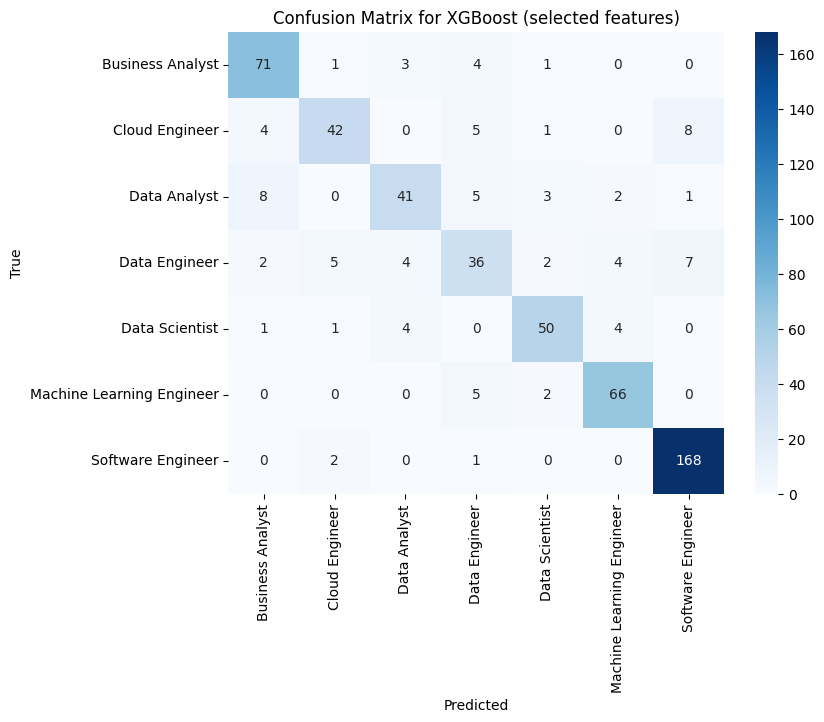

In [115]:
# Classification report for XGBoost
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for XGBoost (selected features)')

In [ ]:
# Detailed classification report
cr = classification_report(y_test, preds, target_names=le.classes_)
print(cr)

                           precision    recall  f1-score   support

         Business Analyst       0.83      0.89      0.86        80
           Cloud Engineer       0.82      0.70      0.76        60
             Data Analyst       0.79      0.68      0.73        60
            Data Engineer       0.64      0.60      0.62        60
           Data Scientist       0.85      0.83      0.84        60
Machine Learning Engineer       0.87      0.90      0.89        73
        Software Engineer       0.91      0.98      0.95       171

                 accuracy                           0.84       564
                macro avg       0.82      0.80      0.81       564
             weighted avg       0.84      0.84      0.84       564



In [8]:
cat_params={'bootstrap_type': 'Bernoulli', 'iterations': 503, 'depth': 4, 'learning_rate': 0.029389913946684096, 'l2_leaf_reg': 3.3009818475938475e-05, 'border_count': 70, 'random_strength': 5.6269077057556e-07, 'colsample_bylevel': 0.5244573201523294, 'auto_class_weights': 'SqrtBalanced', 'subsample': 0.8321419225053766, 'grow_policy': 'Lossguide', 'min_data_in_leaf': 49}
cb = CatBoostClassifier(**cat_params, random_state=42, verbose=0)
calibration = CalibratedClassifierCV(cb, method='isotonic', cv=5)
calibration.fit(X_train_transformed, y_train)
calibrated_preds = calibration.predict(X_test_transformed)

In [12]:
joblib.dump(calibration, '../models/calibrated_catboost.joblib')

['../models/calibrated_catboost.joblib']

In [9]:
cat_cr = classification_report(y_test, calibrated_preds, target_names=le.classes_)
print(cat_cr)

                           precision    recall  f1-score   support

         Business Analyst       0.85      0.91      0.88        80
           Cloud Engineer       0.80      0.72      0.75        60
             Data Analyst       0.74      0.72      0.73        60
            Data Engineer       0.65      0.60      0.63        60
           Data Scientist       0.86      0.80      0.83        60
Machine Learning Engineer       0.89      0.89      0.89        73
        Software Engineer       0.92      0.98      0.95       171

                 accuracy                           0.84       564
                macro avg       0.82      0.80      0.81       564
             weighted avg       0.84      0.84      0.84       564



In [18]:
explainer = shap.TreeExplainer(cb)
shap_values = explainer(X_test_transformed)

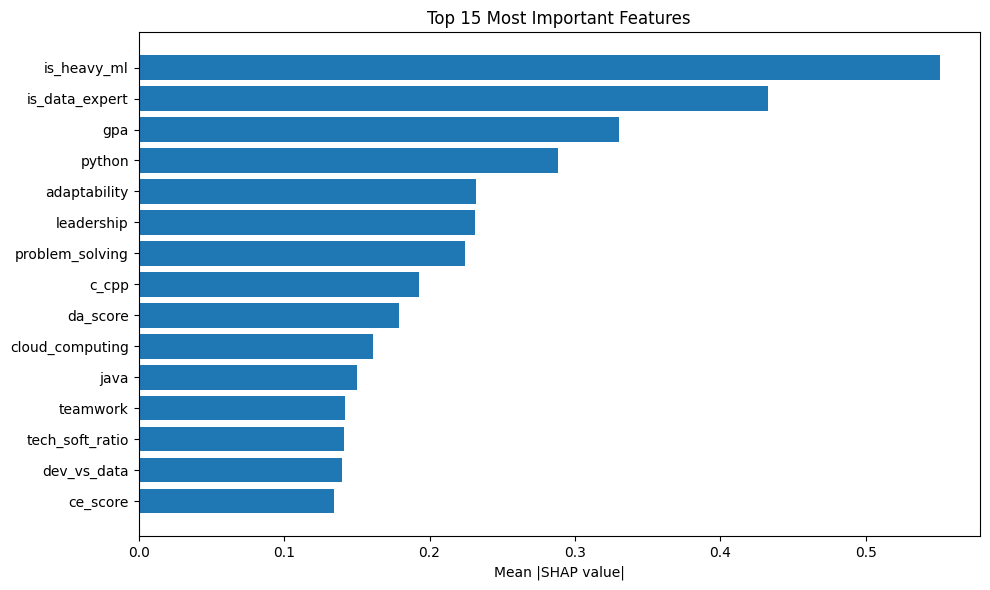

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Top 15 most important features (Mean Impact)")
mean_abs_shap = np.abs(shap_values.values).mean(axis=(0, 2))  
feature_importance = pd.DataFrame({
    'Feature': X_test_transformed.columns,
    'Importance': mean_abs_shap
}).sort_values('Importance', ascending=False).head(15)

plt.barh(range(len(feature_importance)), feature_importance['Importance'].values)
plt.yticks(range(len(feature_importance)), feature_importance['Feature'].values)
plt.xlabel('Mean |SHAP value|')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

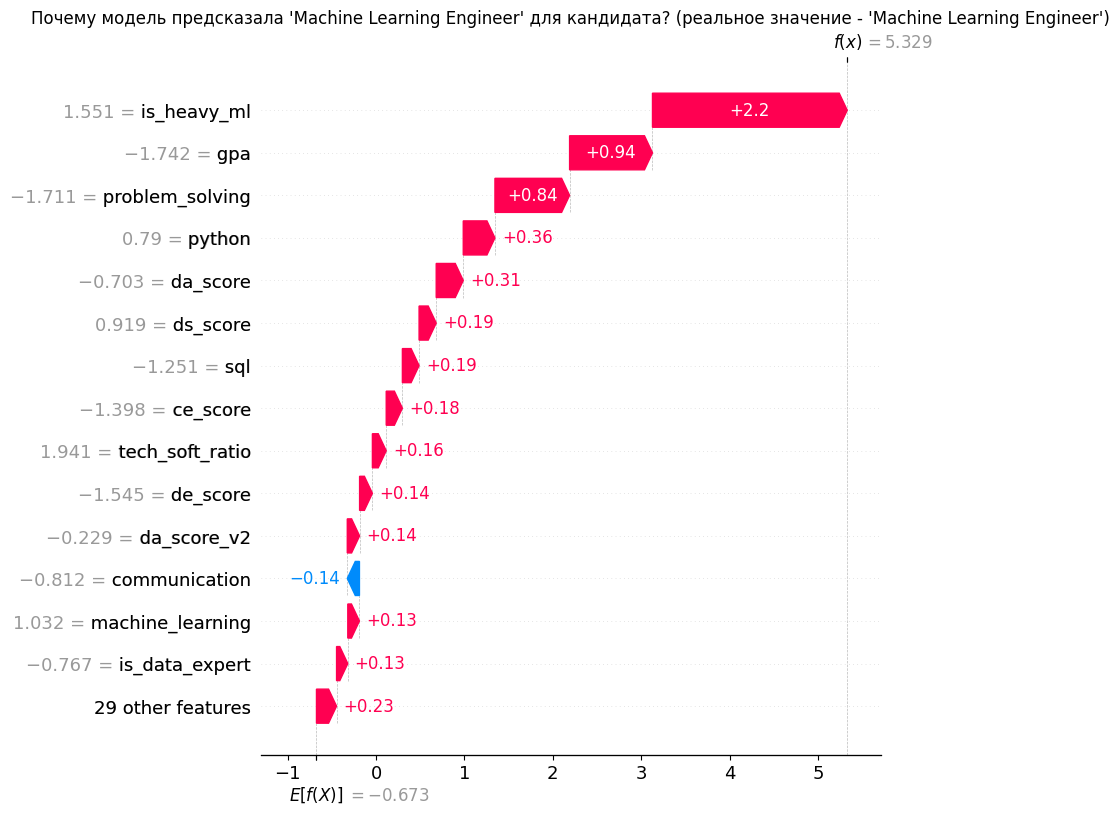

In [24]:
# Выбрать случайный образец из тестового набора
sample_idx = np.random.choice(len(X_test_transformed), 1)[0]
X_sample = X_test_transformed.iloc[sample_idx:sample_idx+1]

# Получить предсказание для этого образца (CatBoost возвращает закодированный класс)
prediction = cb.predict(X_sample)
prediction_idx = int(prediction[0]) if hasattr(prediction[0], '__len__') == False else int(prediction[0, 0])

# Получить SHAP значения для предсказанного класса
sample_shap = shap_values[sample_idx, :, prediction_idx]

# Реальное значение
real_value = y_test[sample_idx]
real_career = le.inverse_transform([real_value])[0]
predicted_career = le.inverse_transform([prediction_idx])[0]

# Создать waterfall plot
plt.figure(figsize=(12, 8))
plt.title(f"Почему модель предсказала '{predicted_career}' для кандидата? (реальное значение - '{real_career}')")
shap.plots.waterfall(shap.Explanation(values=sample_shap, 
                                      base_values=explainer.expected_value[prediction_idx],
                                      data=X_sample.values[0],
                                      feature_names=X_sample.columns), 
                     max_display=15, show=True)